# Laboratorio 4 — Análisis de Datos Geoespaciales

Análisis geoespacial de los lagos **Atitlán** y **Amatitlán** utilizando imágenes
**Sentinel-2**, con el objetivo de calcular índices de vegetación (NDVI), de agua
(NDWI) y un índice de detección de cianobacteria (chlorophyll-a) para un conjunto
de fechas oficiales proporcionadas por la cátedra.

Este notebook cubre los **ejercicios 1 al 4** del laboratorio y está diseñado para
ejecutarse de arriba hacia abajo de forma reproducible: los resultados que ya
existen en `data/` se reutilizan y **no se vuelven a descargar**.

## 1. Configuración del entorno

Se agrupan aquí todas las librerías utilizadas en el notebook: manejo de datos
(`numpy`, `pandas`, `xarray`), visualización (`matplotlib`), acceso a Copernicus
Data Space vía `openeo`, y acceso a Sentinel Hub (`sentinelhub`) para el cálculo
de cianobacteria.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import openeo

from datetime import datetime, timedelta
from dotenv import load_dotenv

from sentinelhub import (
    SHConfig,
    SentinelHubRequest,
    DataCollection,
    MimeType,
    CRS,
    BBox,
    bbox_to_dimensions,
)

### Credenciales

Las credenciales de Sentinel Hub se leen desde un archivo `.env` (ignorado por
git) y **nunca** se escriben ni se imprimen directamente en el notebook.

In [2]:
load_dotenv(override=True)

config = SHConfig()

config.sh_client_id = os.getenv("SH_CLIENT_ID")
config.sh_client_secret = os.getenv("SH_CLIENT_SECRET")

config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

assert config.sh_client_id, "SH_CLIENT_ID no configurado"
assert config.sh_client_secret, "SH_CLIENT_SECRET no configurado"

## 2. Conexión con Copernicus / openEO

`openEO` se utiliza para acceder y procesar los datos Sentinel-2 (nivel L2A)
directamente en los servidores de Copernicus Data Space, sin necesidad de
descargar escenas completas. La autenticación se realiza mediante OIDC.

In [3]:
connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
).authenticate_oidc()

Authenticated using refresh token.


## 3. Regiones y fechas de estudio

### Regiones

Coordenadas de los bounding box de ambos lagos, proporcionadas por la cátedra.
Los archivos `lago_amatitlan.geojson` y `lago_atitlan.geojson` incluidos en el
proyecto representan estas mismas extensiones rectangulares y se conservan como
recurso de referencia del laboratorio.

In [4]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

### Fechas oficiales

Se utilizan exclusivamente las 11 fechas oficiales por lago indicadas por la
cátedra (22 fechas en total).

In [5]:
fechas_amatitlan = [
    "2025-01-28",
    "2025-04-15",
    "2025-04-28",
    "2025-11-24",
    "2026-01-08",
    "2026-02-02",
    "2026-02-07",
    "2026-03-29",
    "2026-04-13",
    "2026-04-28",
    "2026-06-19"
]

fechas_atitlan = [
    "2025-01-18",
    "2025-04-13",
    "2025-05-13",
    "2025-07-17",
    "2025-11-21",
    "2025-12-29",
    "2026-02-12",
    "2026-03-24",
    "2026-04-13",
    "2026-04-28",
    "2026-07-22"
]

## 4. Obtención de imágenes Sentinel-2

Se utiliza la colección `SENTINEL2_L2A` (nivel de procesamiento **L2A**, reflectancia
de superficie corregida atmosféricamente). No debe confundirse con "Sentinel-2A",
que es uno de los satélites de la constelación (2A/2B/2C); L2A es el nivel de
procesamiento del producto.

Para NDVI y NDWI solo se necesitan las bandas `B03`, `B04` y `B08`:

- NDVI utiliza `B04` (rojo) y `B08` (infrarrojo cercano).
- NDWI utiliza `B03` (verde) y `B08` (infrarrojo cercano).

Se crea un DataCube por lago cubriendo todo el período que contiene las fechas
oficiales.

In [6]:
amatitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=lago_amatitlan,
    temporal_extent=["2025-01-28", "2026-06-20"],
    bands=["B03", "B04", "B08"]
)

atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=lago_atitlan,
    temporal_extent=["2025-01-18", "2026-07-23"],
    bands=["B03", "B04", "B08"]
)

### Selección de las 11 fechas oficiales

En lugar de crear un DataCube independiente por fecha, se utiliza
`aggregate_temporal` sobre el DataCube completo, indicando un intervalo de un
día (`[fecha, día_siguiente]`) por cada fecha oficial. Los intervalos se
generan automáticamente a partir de `fechas_amatitlan` y `fechas_atitlan` para
evitar duplicar las fechas manualmente.

El reductor `mean` combina aquí las observaciones que caen dentro de cada
intervalo diario (normalmente una sola adquisición); **no** es todavía el
promedio espacial del lago.

In [7]:
def crear_intervalos(fechas):
    intervalos = []

    for fecha in fechas:
        inicio = datetime.strptime(fecha, "%Y-%m-%d")
        fin = inicio + timedelta(days=1)

        intervalos.append([
            inicio.strftime("%Y-%m-%d"),
            fin.strftime("%Y-%m-%d")
        ])

    return intervalos

In [8]:
intervalos_amatitlan = crear_intervalos(fechas_amatitlan)
intervalos_atitlan = crear_intervalos(fechas_atitlan)

In [9]:
amatitlan_fechas = amatitlan_cube.aggregate_temporal(
    intervals=intervalos_amatitlan,
    reducer="mean"
)

atitlan_fechas = atitlan_cube.aggregate_temporal(
    intervals=intervalos_atitlan,
    reducer="mean"
)

## 5. Cálculo de NDVI y NDWI

**NDVI** (índice de vegetación de diferencia normalizada):

```
NDVI = (B08 - B04) / (B08 + B04)
```

B08 corresponde al infrarrojo cercano y B04 al rojo.

In [10]:
ndvi_amatitlan = (
    amatitlan_fechas.band("B08") - amatitlan_fechas.band("B04")
) / (
    amatitlan_fechas.band("B08") + amatitlan_fechas.band("B04")
)

ndvi_atitlan = (
    atitlan_fechas.band("B08") - atitlan_fechas.band("B04")
) / (
    atitlan_fechas.band("B08") + atitlan_fechas.band("B04")
)

**NDWI** (índice de agua de diferencia normalizada), utilizado para distinguir
superficies de agua:

```
NDWI = (B03 - B08) / (B03 + B08)
```

In [11]:
ndwi_amatitlan = (
    amatitlan_fechas.band("B03") - amatitlan_fechas.band("B08")
) / (
    amatitlan_fechas.band("B03") + amatitlan_fechas.band("B08")
)

ndwi_atitlan = (
    atitlan_fechas.band("B03") - atitlan_fechas.band("B08")
) / (
    atitlan_fechas.band("B03") + atitlan_fechas.band("B08")
)

## 6. Detección de cianobacteria con Sentinel Hub

La cianobacteria (chlorophyll-a) se procesa mediante **Sentinel Hub**, usando la
colección Sentinel-2 **L1C** — no el DataCube L2A de openEO usado para NDVI/NDWI.
Ambas fuentes de datos se mantienen separadas.

In [12]:
s2_l1c = DataCollection.SENTINEL2_L1C.define_from(
    "s2l1c",
    service_url=config.sh_base_url
)

### BBox y resolución

Se construye un `BBox` por lago a partir de las mismas coordenadas de la
sección 3, y se calculan las dimensiones del raster con una resolución de
20 metros por píxel (sin hardcodear las dimensiones).

In [13]:
bbox_amatitlan = BBox(
    bbox=[
        lago_amatitlan["west"],
        lago_amatitlan["south"],
        lago_amatitlan["east"],
        lago_amatitlan["north"]
    ],
    crs=CRS.WGS84
)

bbox_atitlan = BBox(
    bbox=[
        lago_atitlan["west"],
        lago_atitlan["south"],
        lago_atitlan["east"],
        lago_atitlan["north"]
    ],
    crs=CRS.WGS84
)

size_amatitlan = bbox_to_dimensions(bbox_amatitlan, resolution=20)
size_atitlan = bbox_to_dimensions(bbox_atitlan, resolution=20)

print("Tamaño raster Amatitlán:", size_amatitlan)
print("Tamaño raster Atitlán:", size_atitlan)

Tamaño raster Amatitlán: (670, 458)
Tamaño raster Atitlán: (1365, 875)


### Evalscript de cianobacteria

Versión final del Evalscript utilizado. Primero clasifica cada píxel como
agua/no-agua combinando varios índices espectrales (MNDWI, NDWI, AWEI, DBSI,
NDVI); para los píxeles de agua calcula el NDCI (`B05`, `B04`) y estima
chlorophyll-a a partir de un ajuste polinómico del NDCI. Devuelve `NaN` para
píxeles que no son agua y para valores de chlorophyll-a negativos.

In [14]:
evalscript_cyano = """
//VERSION=3

function setup() {
    return {
        input: [{
            bands: [
                "B02", "B03", "B04", "B05",
                "B07", "B08", "B8A",
                "B11", "B12", "dataMask"
            ]
        }],
        output: {
            bands: 1,
            sampleType: "FLOAT32"
        }
    };
}

function evaluatePixel(s) {

    // ----- DETECCIÓN DE AGUA -----
    let ndvi = (s.B08 - s.B04) / (s.B08 + s.B04);
    let mndwi = (s.B03 - s.B11) / (s.B03 + s.B11);
    let ndwi = (s.B03 - s.B08) / (s.B03 + s.B08);
    let ndwi_leaves = (s.B08 - s.B11) / (s.B08 + s.B11);

    let aweish =
        s.B02 + 2.5 * s.B03
        - 1.5 * (s.B08 + s.B11)
        - 0.25 * s.B12;

    let aweinsh =
        4 * (s.B03 - s.B11)
        - (0.25 * s.B08 + 2.75 * s.B11);

    let dbsi =
        ((s.B11 - s.B03) / (s.B11 + s.B03))
        - ndvi;

    let water =
        mndwi > 0.42 ||
        ndwi > 0.4 ||
        aweinsh > 0.1879 ||
        aweish > 0.1112 ||
        ndvi < -0.2 ||
        ndwi_leaves > 1;

    // Filtro de áreas urbanas / suelo desnudo
    if (water && (aweinsh <= -0.03 || dbsi > 0)) {
        water = false;
    }

    // Si no hay datos o no es agua -> NaN
    if (s.dataMask == 0 || !water) {
        return [NaN];
    }

    // ----- NDCI -----
    let ndci = (s.B05 - s.B04) / (s.B05 + s.B04);

    // ----- CHLOROPHYLL-A -----
    let chl =
        826.57 * Math.pow(ndci, 3)
        - 176.43 * Math.pow(ndci, 2)
        + 19 * ndci
        + 4.071;

    // Eliminar valores negativos
    if (chl < 0) {
        return [NaN];
    }

    return [chl];
}
"""

### Función `obtener_cyano`

Construye y ejecuta un `SentinelHubRequest` para una fecha, bbox y tamaño de
raster dados.

In [15]:
def obtener_cyano(fecha, bbox, size):
    inicio = datetime.strptime(fecha, "%Y-%m-%d")
    fin = inicio + timedelta(days=1)

    request = SentinelHubRequest(
        evalscript=evalscript_cyano,

        input_data=[
            SentinelHubRequest.input_data(
                data_collection=s2_l1c,
                time_interval=(
                    inicio.strftime("%Y-%m-%d"),
                    fin.strftime("%Y-%m-%d")
                )
            )
        ],

        responses=[
            SentinelHubRequest.output_response(
                "default",
                MimeType.TIFF
            )
        ],

        bbox=bbox,
        size=size,
        config=config
    )

    return request.get_data()[0]

### Procesamiento de las 22 fechas (11 por lago)

Los rasters de cianobacteria se guardan en `data/cyano/<lago>/<fecha>.npy`.
Para que el notebook sea reproducible sin volver a llamar la API en cada
reinicio del kernel, `obtener_cyano_lago` primero revisa si el `.npy` ya
existe: si existe lo carga desde disco, y solo si falta llama a Sentinel Hub
y lo guarda.

In [16]:
def obtener_cyano_lago(nombre_lago, fechas, bbox, size):
    carpeta = f"data/cyano/{nombre_lago}"
    os.makedirs(carpeta, exist_ok=True)

    resultados = {}

    for fecha in fechas:
        ruta = f"{carpeta}/{fecha}.npy"

        if os.path.exists(ruta):
            resultados[fecha] = np.load(ruta)
            continue

        print("Procesando:", nombre_lago, fecha)
        raster = obtener_cyano(fecha, bbox, size)
        np.save(ruta, raster)
        resultados[fecha] = raster

    return resultados

In [17]:
cyano_amatitlan = obtener_cyano_lago(
    "amatitlan", fechas_amatitlan, bbox_amatitlan, size_amatitlan
)

cyano_atitlan = obtener_cyano_lago(
    "atitlan", fechas_atitlan, bbox_atitlan, size_atitlan
)

print("Amatitlán:", len(cyano_amatitlan), "raster")
print("Atitlán:", len(cyano_atitlan), "raster")

Amatitlán: 11 raster
Atitlán: 11 raster


## 7. Descarga y almacenamiento de resultados

Los resultados de NDVI/NDWI se descargan como NetCDF mediante Batch Jobs de
openEO. Se usa `validate=False` porque el endpoint de validación previa del
backend presentó desconexiones durante las pruebas.

Antes de crear un Batch Job se comprueba si el archivo de salida ya existe,
para no volver a descargar ni gastar cuota de la API innecesariamente.

In [18]:
def descargar_datacube(cube, ruta):
    if os.path.exists(ruta):
        print(f"Ya existe: {ruta}")
        return

    carpeta = os.path.dirname(ruta)
    if carpeta:
        os.makedirs(carpeta, exist_ok=True)

    resultado = cube.save_result(format="NetCDF")

    job = connection.create_job(
        resultado,
        validate=False
    )

    job.start_and_wait()

    # job.download_results() está deprecado y siempre espera una carpeta
    # (reparte los assets con nombres que da el backend, no la ruta pedida).
    # get_results().download_file(target=ruta) descarga el único asset
    # NetCDF del job directamente en la ruta exacta solicitada.
    job.get_results().download_file(target=ruta)
    print(f"Descargado: {ruta}")

In [19]:
descargar_datacube(ndvi_amatitlan, "data/indices/amatitlan/ndvi.nc")

Ya existe: data/indices/amatitlan/ndvi.nc


In [20]:
descargar_datacube(ndvi_atitlan, "data/indices/atitlan/ndvi.nc")

Ya existe: data/indices/atitlan/ndvi.nc


In [ ]:
descargar_datacube(ndwi_amatitlan, "data/indices/amatitlan/ndwi.nc")

In [ ]:
descargar_datacube(ndwi_atitlan, "data/indices/atitlan/ndwi.nc")

Los rasters de cianobacteria ya quedaron guardados en `data/cyano/amatitlan/`
y `data/cyano/atitlan/` en la sección anterior (un `.npy` por fecha).

Estructura final de `data/`:

```
data/
├── indices/
│   ├── amatitlan/
│   │   ├── ndvi.nc
│   │   └── ndwi.nc
│   └── atitlan/
│       ├── ndvi.nc
│       └── ndwi.nc
└── cyano/
    ├── amatitlan/   (11 archivos .npy)
    └── atitlan/     (11 archivos .npy)
```

## 8. Verificación y visualización de índices

### Cianobacteria

Un resumen estadístico compacto (mínimo, máximo, promedio, cantidad de `NaN`)
por fecha y lago, en forma de tabla en lugar de imprimir cada raster por
separado.

In [21]:
def resumen_raster(raster):
    return {
        "min": np.nanmin(raster),
        "max": np.nanmax(raster),
        "mean": np.nanmean(raster),
        "nan": int(np.isnan(raster).sum())
    }


filas = []

for lago, cyano_lago in [("Amatitlán", cyano_amatitlan), ("Atitlán", cyano_atitlan)]:
    for fecha, raster in cyano_lago.items():
        fila = {"lago": lago, "fecha": fecha}
        fila.update(resumen_raster(raster))
        filas.append(fila)

resumen_cyano = pd.DataFrame(filas)
resumen_cyano

,lago,fecha,min,max,mean,nan
0,Amatitlán,2025-01-28,0.064380,21.600559,4.437029,269984
1,Amatitlán,2025-04-15,0.002657,21.943108,4.531987,270399
2,Amatitlán,2025-04-28,0.058023,34.348564,5.752518,270409
3,Amatitlán,2025-11-24,0.062436,115.434052,4.685636,270156
4,Amatitlán,2026-01-08,0.190948,131.243958,6.694201,269950
5,Amatitlán,2026-02-02,0.017803,14.016261,4.291014,270659
6,Amatitlán,2026-02-07,0.264614,15.427299,4.310813,270082
7,Amatitlán,2026-03-29,0.743057,49.387218,6.437429,269970
8,Amatitlán,2026-04-13,0.000348,28.158697,6.739648,269812
9,Amatitlán,2026-04-28,0.612012,46.144222,9.915771,271734


### NDVI / NDWI

Para cada NetCDF se verifica que la dimensión temporal sea 11, que las fechas
sean las esperadas, y las dimensiones espaciales y variables disponibles. Si
un archivo todavía no ha sido generado (por ejemplo NDWI antes de ejecutar la
sección 7), se indica en lugar de fallar.

In [22]:
def verificar_indice(ruta, fechas_esperadas):
    if not os.path.exists(ruta):
        print(f"{ruta}: no generado todavía")
        return

    ds = xr.open_dataset(ruta)

    n_fechas = ds.sizes.get("t")
    fechas_ds = pd.to_datetime(ds["t"].values).strftime("%Y-%m-%d").tolist()

    print(f"{ruta}")
    print("  dimensiones:", dict(ds.sizes))
    print("  variables:", list(ds.data_vars))
    print("  fechas correctas:", fechas_ds == fechas_esperadas)
    print("  n fechas == 11:", n_fechas == 11)

    ds.close()


for ruta, fechas in [
    ("data/indices/amatitlan/ndvi.nc", fechas_amatitlan),
    ("data/indices/amatitlan/ndwi.nc", fechas_amatitlan),
    ("data/indices/atitlan/ndvi.nc", fechas_atitlan),
    ("data/indices/atitlan/ndwi.nc", fechas_atitlan),
]:
    verificar_indice(ruta, fechas)

data/indices/amatitlan/ndvi.nc
  dimensiones: {'t': 11, 'x': 1360, 'y': 917}
  variables: ['crs', 'var']
  fechas correctas: True
  n fechas == 11: True
data/indices/amatitlan/ndwi.nc: no generado todavía
data/indices/atitlan/ndvi.nc
  dimensiones: {'t': 11, 'x': 2759, 'y': 1751}
  variables: ['crs', 'var']
  fechas correctas: True
  n fechas == 11: True
data/indices/atitlan/ndwi.nc: no generado todavía


### Visualización de cianobacteria

Función reutilizable para visualizar un raster de chlorophyll-a. Los
percentiles 2 y 98 se usan únicamente para mejorar el contraste visual; no
modifican los valores originales del raster.

In [23]:
def visualizar_cyano(raster, lago, fecha):
    vmin = np.nanpercentile(raster, 2)
    vmax = np.nanpercentile(raster, 98)

    plt.figure(figsize=(10, 6))

    plt.imshow(
        raster,
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(label="Chlorophyll-a")
    plt.title(f"{lago} - Cianobacteria - {fecha}")
    plt.axis("off")
    plt.show()

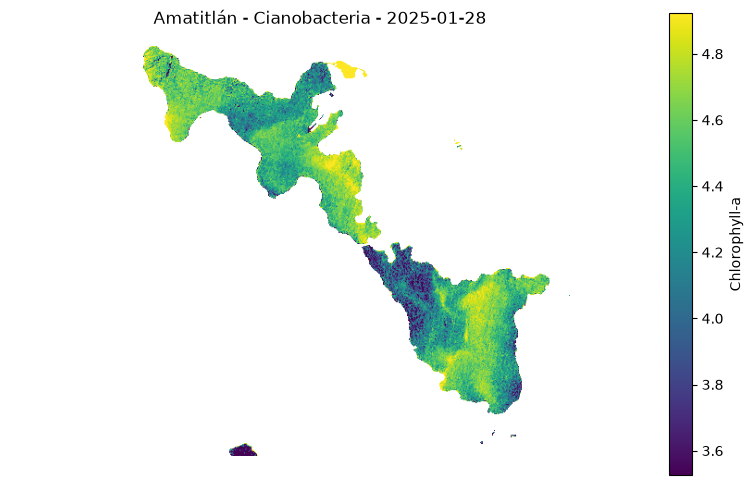

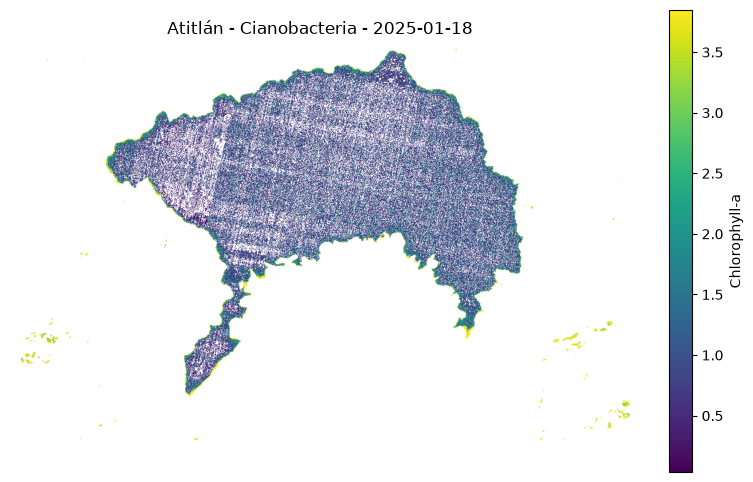

In [24]:
visualizar_cyano(cyano_amatitlan[fechas_amatitlan[0]], "Amatitlán", fechas_amatitlan[0])
visualizar_cyano(cyano_atitlan[fechas_atitlan[0]], "Atitlán", fechas_atitlan[0])

## 9. Análisis temporal de cianobacteria

**Ejercicio 4.** A partir de los rasters de cianobacteria se calcula el índice
promedio por lago y fecha, se visualiza su evolución temporal, y se
identifican posibles picos de floración.

Los valores `NaN` representan píxeles que no son agua o sin datos válidos, y
se ignoran al calcular el promedio mediante `np.nanmean`.

In [25]:
filas_promedio = []

for lago, cyano_lago, fechas in [
    ("Amatitlán", cyano_amatitlan, fechas_amatitlan),
    ("Atitlán", cyano_atitlan, fechas_atitlan),
]:
    for fecha in fechas:
        filas_promedio.append({
            "lago": lago,
            "fecha": fecha,
            "cyano_promedio": np.nanmean(cyano_lago[fecha])
        })

df_cyano = pd.DataFrame(filas_promedio)
df_cyano["fecha"] = pd.to_datetime(df_cyano["fecha"])
df_cyano = df_cyano.sort_values(["lago", "fecha"]).reset_index(drop=True)
df_cyano

,lago,fecha,cyano_promedio
0,Amatitlán,2025-01-28,4.437029
1,Amatitlán,2025-04-15,4.531987
2,Amatitlán,2025-04-28,5.752518
3,Amatitlán,2025-11-24,4.685636
4,Amatitlán,2026-01-08,6.694201
5,Amatitlán,2026-02-02,4.291014
6,Amatitlán,2026-02-07,4.310813
7,Amatitlán,2026-03-29,6.437429
8,Amatitlán,2026-04-13,6.739648
9,Amatitlán,2026-04-28,9.915771


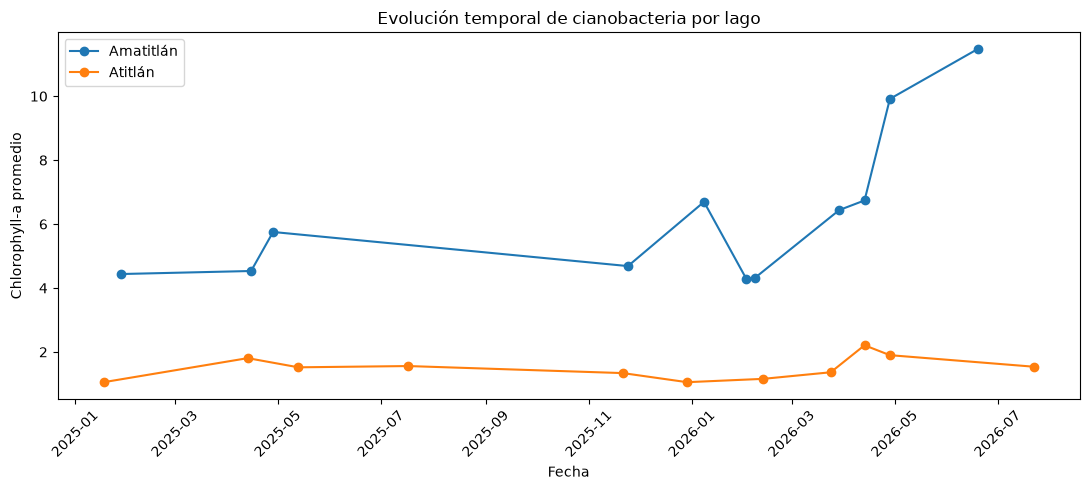

In [26]:
plt.figure(figsize=(11, 5))

for lago, grupo in df_cyano.groupby("lago"):
    plt.plot(grupo["fecha"], grupo["cyano_promedio"], marker="o", label=lago)

plt.xlabel("Fecha")
plt.ylabel("Chlorophyll-a promedio")
plt.title("Evolución temporal de cianobacteria por lago")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
picos = df_cyano.loc[df_cyano.groupby("lago")["cyano_promedio"].idxmax()]
picos[["lago", "fecha", "cyano_promedio"]]

,lago,fecha,cyano_promedio
10,Amatitlán,2026-06-19,11.477148
19,Atitlán,2026-04-13,2.208212


### Interpretación de los datos

El análisis temporal muestra dos comportamientos diferentes entre los lagos de Amatitlán y Atitlán. En Amatitlán, los valores de cianobacteria presentan fluctuaciones a lo largo del período, pero es notable la tendencia al aumento, más que todo en 2026. Al inicio del análisis se obtuvo un promedio de aproximadamente 4.44, mientras que durante el mes de abril de 2025 se tuvo el primer incremento hasta 5.75. Después, los valores disminuyeron y volvieron a fluctuar, llegando incluso a valores cercanos a 4.3 durante febrero de 2026. En marzo de 2026 se observa un incremento más marcado: el promedio pasó de 6.44 el 29 de marzo a 6.74 el 13 de abril, 9.92 el 28 de abril y, por último, alcanzó el máximo de la serie, 11.48, el 19 de junio de 2026. Por esto, se puede considerar que finales de abril y junio de 2026 fueron los períodos más críticos observados para Amatitlán.

En Atitlán pasa algo diferente (un poco esperado): los valores se mantienen considerablemente más bajos y presentan fluctuaciones más moderadas. Durante la mayor parte de la serie, los promedios se encuentran aproximadamente entre 1.0 y 1.8, sin mostrar una tendencia sostenida al aumento. El valor máximo se registró el 13 de abril de 2026, con 2.21, seguido por una disminución a 1.90 el 28 de abril y 1.54 en julio. Esto nos indica que, dentro de las fechas analizadas, Atitlán presentó un comportamiento más estable y una menor intensidad del indicador de cianobacteria en comparación con Amatitlán.

Un patrón que se nos hace interesante es que ambos lagos presentan incrementos alrededor de marzo y abril de 2026. En Amatitlán, este incremento continúa y se intensifica durante los meses posteriores, mientras que en Atitlán alcanza su máximo en abril y luego disminuye. Esta coincidencia temporal podría sugerir la presencia de factores ambientales o estacionales que favorezcan la proliferación de cianobacterias durante este período.

Entre los posibles factores asociados se encuentran cambios en la temperatura, disponibilidad de nutrientes y condiciones de circulación o estancamiento del agua, factores que pueden favorecer la floración de cianobacterias. Sin embargo, estas variables no fueron medidas en el análisis, por lo que los resultados que obtuvimos mediante las imágenes satelitales no permiten establecer una relación causal.

En general, los resultados obtenidos muestran que Amatitlán presentó valores mayores y variaciones temporales más pronunciadas que Atitlán, destacando el fuerte incremento observado entre marzo y junio de 2026. Por otro lado, Atitlán mantuvo valores relativamente bajos durante todo el período analizado.